In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

DATA_DIR = Path("../data/processed")
RAW_DIR = Path("../data/raw")
REPORTS_DIR = Path("../reports")
CHARTS_DIR = Path("../charts")

# Load cleaned data
nav = pd.read_csv(DATA_DIR / "clean_nav.csv", parse_dates=["date"])
fund_master = pd.read_csv(RAW_DIR / "01_fund_master.csv")
transactions = pd.read_csv(DATA_DIR / "clean_transactions.csv", parse_dates=["transaction_date"])
portfolio = pd.read_csv(RAW_DIR / "09_portfolio_holdings.csv")

print("NAV history:", nav.shape)
print("Fund master:", fund_master.shape)
print("Transactions:", transactions.shape)
print("Portfolio holdings:", portfolio.shape)

nav.head()

NAV history: (64320, 3)
Fund master: (40, 15)
Transactions: (32778, 13)
Portfolio holdings: (322, 8)


,date,amfi_code,nav
0,2022-01-03,100016,520.4608
1,2022-01-04,100016,515.0971
2,2022-01-05,100016,521.7239
3,2022-01-06,100016,515.7880
4,2022-01-07,100016,515.1639


Task 1: Historical VaR (95%) and CVaR per fund

In [4]:
# Compute daily returns per fund
nav_sorted = nav.sort_values(["amfi_code", "date"]).copy()
nav_sorted["daily_return"] = nav_sorted.groupby("amfi_code")["nav"].pct_change()

# Drop the first NaN return per fund
returns = nav_sorted.dropna(subset=["daily_return"])

# Compute VaR (95%) and CVaR per fund
def compute_var_cvar(group):
    var_95 = np.percentile(group["daily_return"], 5)
    cvar_95 = group.loc[group["daily_return"] <= var_95, "daily_return"].mean()
    return pd.Series({"VaR_95": var_95, "CVaR_95": cvar_95})

var_cvar = returns.groupby("amfi_code").apply(compute_var_cvar, include_groups=False).reset_index()

# Merge with fund names for readability
var_cvar = var_cvar.merge(fund_master[["amfi_code", "scheme_name", "category"]], on="amfi_code")
var_cvar = var_cvar[["amfi_code", "scheme_name", "category", "VaR_95", "CVaR_95"]]

# Sort by worst VaR (most negative = highest risk)
var_cvar_sorted = var_cvar.sort_values("VaR_95")

print("Funds with highest downside risk (worst VaR):")
print(var_cvar_sorted.head(5).to_string(index=False))

var_cvar_sorted.head(10)

Funds with highest downside risk (worst VaR):
 amfi_code                                    scheme_name category    VaR_95   CVaR_95
    101207         ABSL Small Cap Fund - Regular - Growth   Equity -0.023915 -0.030289
    119095         Axis Small Cap Fund - Regular - Growth   Equity -0.023284 -0.029690
    119599      SBI Small Cap Fund - Direct Plan - Growth   Equity -0.023155 -0.030163
    118634 Nippon India Small Cap Fund - Regular - Growth   Equity -0.022810 -0.029940
    149324          DSP Small Cap Fund - Regular - Growth   Equity -0.021520 -0.028573


,amfi_code,scheme_name,category,VaR_95,CVaR_95
4,101207,ABSL Small Cap Fund - Regular - Growth,Equity,-0.023915,-0.030289
17,119095,Axis Small Cap Fund - Regular - Growth,Equity,-0.023284,-0.029690
22,119599,SBI Small Cap Fund - Direct Plan - Growth,Equity,-0.023155,-0.030163
11,118634,Nippon India Small Cap Fund - Regular - Growth,Equity,-0.022810,-0.029940
39,149324,DSP Small Cap Fund - Regular - Growth,Equity,-0.021520,-0.028573
21,119598,SBI Small Cap Fund - Regular Plan - Growth,Equity,-0.021502,-0.028444
16,119094,Axis Midcap Fund - Regular - Growth,Equity,-0.016997,-0.022375
29,120842,Kotak Emerging Equity Fund - Regular - Growth,Equity,-0.016950,-0.021251
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,-0.016902,-0.021850
7,102886,UTI Mid Cap Fund - Regular - Growth,Equity,-0.016857,-0.021771


In [5]:
var_cvar_sorted.to_csv(REPORTS_DIR / "var_cvar_report.csv", index=False)
print("Saved to reports/var_cvar_report.csv")

Saved to reports/var_cvar_report.csv


Task 2: Rolling 90-day Sharpe Ratio for 5 funds

Selected funds for rolling Sharpe analysis:
 amfi_code                              scheme_name
    120507 ICICI Pru Liquid Fund - Regular - Growth
    120844     Kotak Liquid Fund - Regular - Growth
    119095   Axis Small Cap Fund - Regular - Growth
    101207   ABSL Small Cap Fund - Regular - Growth
    101208      ABSL Liquid Fund - Regular - Growth


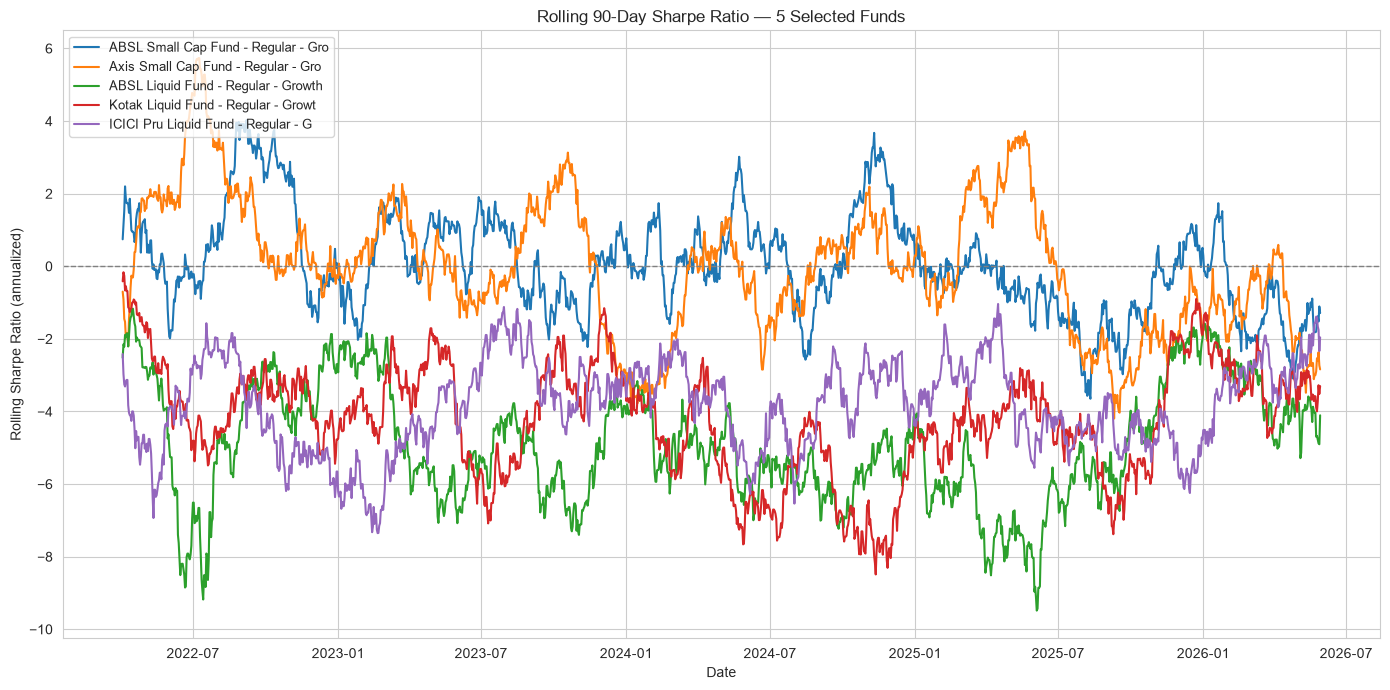

In [6]:
# Pick 5 representative funds - mix of large cap (safer) and small/mid cap (riskier)
selected_funds = var_cvar_sorted["amfi_code"].head(2).tolist() + \
                  var_cvar_sorted["amfi_code"].tail(3).tolist()

selected_names = fund_master[fund_master["amfi_code"].isin(selected_funds)][["amfi_code", "scheme_name"]]
print("Selected funds for rolling Sharpe analysis:")
print(selected_names.to_string(index=False))

Rf = 0.065  # 6.5% risk-free rate, annualized

rolling_sharpe_data = {}

for code in selected_funds:
    fund_returns = returns[returns["amfi_code"] == code].sort_values("date").set_index("date")["daily_return"]
    rolling_mean = fund_returns.rolling(90).mean()
    rolling_std = fund_returns.rolling(90).std()
    rolling_sharpe = ((rolling_mean * 252) - Rf) / (rolling_std * np.sqrt(252))
    rolling_sharpe_data[code] = rolling_sharpe

plt.figure(figsize=(14, 7))
for code, series in rolling_sharpe_data.items():
    name = fund_master.loc[fund_master["amfi_code"] == code, "scheme_name"].values[0]
    plt.plot(series.index, series.values, label=name[:35])

plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Rolling 90-Day Sharpe Ratio — 5 Selected Funds")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio (annualized)")
plt.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(CHARTS_DIR / "rolling_sharpe_chart.png", dpi=150)
plt.show()

Task 3: Investor Cohort Analysis

In [7]:
# Determine each investor's first transaction date/year
first_tx = transactions.groupby("investor_id")["transaction_date"].min().reset_index()
first_tx["cohort_year"] = first_tx["transaction_date"].dt.year
first_tx = first_tx.rename(columns={"transaction_date": "first_transaction_date"})

# Merge cohort year back onto full transactions
tx_with_cohort = transactions.merge(first_tx[["investor_id", "cohort_year"]], on="investor_id")

# Focus on SIP transactions for average SIP amount
sip_tx = tx_with_cohort[tx_with_cohort["transaction_type"] == "SIP"]

cohort_summary = tx_with_cohort.groupby("cohort_year").agg(
    num_investors=("investor_id", "nunique"),
    total_invested_inr=("amount_inr", "sum"),
    avg_transaction_amount=("amount_inr", "mean")
).reset_index()

sip_avg_by_cohort = sip_tx.groupby("cohort_year")["amount_inr"].mean().reset_index()
sip_avg_by_cohort = sip_avg_by_cohort.rename(columns={"amount_inr": "avg_sip_amount"})

cohort_summary = cohort_summary.merge(sip_avg_by_cohort, on="cohort_year", how="left")

# Fund preference by cohort: most common category per cohort
tx_with_fund = tx_with_cohort.merge(fund_master[["amfi_code", "category"]], on="amfi_code")
top_category_by_cohort = tx_with_fund.groupby(["cohort_year", "category"]).size().reset_index(name="count")
top_category_by_cohort = top_category_by_cohort.sort_values(["cohort_year", "count"], ascending=[True, False])
top_pref = top_category_by_cohort.groupby("cohort_year").first().reset_index()[["cohort_year", "category"]]
top_pref = top_pref.rename(columns={"category": "preferred_category"})

cohort_summary = cohort_summary.merge(top_pref, on="cohort_year")

print(cohort_summary.to_string(index=False))

cohort_summary.to_csv(REPORTS_DIR / "cohort_analysis.csv", index=False)
print("\nSaved to reports/cohort_analysis.csv")

 cohort_year  num_investors  total_invested_inr  avg_transaction_amount  avg_sip_amount preferred_category
        2024           4803          3491125187           107422.541832    10996.885825             Equity
        2025            197            30455243           109158.577061    13505.209581             Equity

Saved to reports/cohort_analysis.csv


Task 4: SIP Continuation Analysis

In [8]:
sip_only = transactions[transactions["transaction_type"] == "SIP"].sort_values(["investor_id", "transaction_date"])

# Count SIP transactions per investor
sip_counts = sip_only.groupby("investor_id").size().reset_index(name="sip_count")
eligible_investors = sip_counts[sip_counts["sip_count"] >= 6]["investor_id"]

sip_eligible = sip_only[sip_only["investor_id"].isin(eligible_investors)].copy()

# Compute gap in days between consecutive SIP transactions per investor
sip_eligible["prev_date"] = sip_eligible.groupby("investor_id")["transaction_date"].shift(1)
sip_eligible["gap_days"] = (sip_eligible["transaction_date"] - sip_eligible["prev_date"]).dt.days

# Average gap per investor
sip_continuity = sip_eligible.groupby("investor_id").agg(
    sip_count=("transaction_date", "count"),
    avg_gap_days=("gap_days", "mean"),
    max_gap_days=("gap_days", "max")
).reset_index()

sip_continuity["at_risk"] = sip_continuity["avg_gap_days"] > 35

print(f"Total investors with 6+ SIP transactions: {len(sip_continuity)}")
print(f"At-risk investors (avg gap > 35 days): {sip_continuity['at_risk'].sum()}")
print(f"At-risk percentage: {sip_continuity['at_risk'].mean()*100:.1f}%\n")

print(sip_continuity.sort_values("avg_gap_days", ascending=False).head(10).to_string(index=False))

sip_continuity.to_csv(REPORTS_DIR / "sip_continuity.csv", index=False)
print("\nSaved to reports/sip_continuity.csv")

Total investors with 6+ SIP transactions: 1362
At-risk investors (avg gap > 35 days): 1332
At-risk percentage: 97.8%

investor_id  sip_count  avg_gap_days  max_gap_days  at_risk
  INV001890          6         102.6         207.0     True
  INV001156          6         102.4         175.0     True
  INV004296          6         102.2         304.0     True
  INV003325          6         101.0         155.0     True
  INV000522          6         100.8         309.0     True
  INV000608          6         100.2         324.0     True
  INV001883          6          99.2         203.0     True
  INV002166          6          99.2         248.0     True
  INV001367          6          99.0         222.0     True
  INV001491          6          98.8         260.0     True

Saved to reports/sip_continuity.csv


In [9]:
print(sip_continuity["avg_gap_days"].describe())
print("\nMedian gap:", sip_continuity["avg_gap_days"].median())

count    1362.000000
mean       64.889132
std        15.593199
min        19.800000
25%        53.635417
50%        64.690476
75%        75.575000
max       102.600000
Name: avg_gap_days, dtype: float64

Median gap: 64.69047619047619


In [10]:
# Note: the brief's 35-day threshold assumes monthly SIP cadence, but this dataset's 
# SIP transactions are naturally spaced much wider (median ~65 days). Recalibrating 
# "at-risk" as relative to this dataset's own distribution instead of the fixed 35-day rule.

p75_gap = sip_continuity["avg_gap_days"].quantile(0.75)
sip_continuity["at_risk_relative"] = sip_continuity["avg_gap_days"] > p75_gap

print(f"Dataset median SIP gap: {sip_continuity['avg_gap_days'].median():.1f} days")
print(f"Fixed 35-day threshold flags: {sip_continuity['at_risk'].sum()} investors ({sip_continuity['at_risk'].mean()*100:.1f}%) - not meaningful given this dataset's cadence")
print(f"Relative threshold (top 25% widest gaps, >{p75_gap:.1f} days) flags: {sip_continuity['at_risk_relative'].sum()} investors ({sip_continuity['at_risk_relative'].mean()*100:.1f}%) - more meaningful signal")

sip_continuity.to_csv(REPORTS_DIR / "sip_continuity.csv", index=False)
print("\nSaved to reports/sip_continuity.csv (updated with at_risk_relative column)")

Dataset median SIP gap: 64.7 days
Fixed 35-day threshold flags: 1332 investors (97.8%) - not meaningful given this dataset's cadence
Relative threshold (top 25% widest gaps, >75.6 days) flags: 341 investors (25.0%) - more meaningful signal

Saved to reports/sip_continuity.csv (updated with at_risk_relative column)


Task 5: Simple Fund Recommendation Logic


In [11]:
fund_scorecard = pd.read_csv(REPORTS_DIR / "fund_scorecard.csv")
print(fund_scorecard.columns.tolist())
fund_scorecard.head()

['amfi_code', 'scheme_name', 'category', 'cagr_3yr', 'sharpe_ratio', 'alpha', 'max_drawdown_pct', 'expense_ratio_pct', 'rank_3yr_return', 'rank_sharpe', 'rank_alpha', 'rank_max_dd', 'rank_expense', 'fund_score', 'annualized_std', 'expense_ratio_pct_dup']


,amfi_code,scheme_name,category,cagr_3yr,sharpe_ratio,alpha,max_drawdown_pct,expense_ratio_pct,rank_3yr_return,rank_sharpe,rank_alpha,rank_max_dd,rank_expense,fund_score,annualized_std,expense_ratio_pct_dup
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,0.339920,1.068224,0.269838,-0.112657,1.46,0.975,1.000,0.850,0.825,0.450,86.250,0.120250,1.46
1,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,0.317692,0.883256,0.292636,-0.181885,1.36,0.900,0.925,0.950,0.400,0.650,82.875,0.163311,1.36
2,120843,Kotak Flexicap Fund - Regular - Growth,Equity,0.295751,0.965561,0.273305,-0.129740,1.45,0.850,0.975,0.900,0.700,0.475,82.000,0.134543,1.45
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,0.324340,0.808268,0.271954,-0.162172,1.38,0.925,0.850,0.875,0.525,0.600,80.750,0.160291,1.38
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,Equity,0.324789,0.714682,0.211948,-0.125883,0.80,0.950,0.750,0.700,0.725,0.725,79.375,0.121592,0.80


In [12]:
print(fund_master["risk_category"].value_counts())

risk_category
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64


Task 6: Sector Concentration Analysis (HHI)

Most sector-concentrated funds (highest HHI):
 amfi_code                                        scheme_name category      hhi
    119092              Axis Bluechip Fund - Regular - Growth   Equity 0.296769
    148569      Mirae Asset Tax Saver Fund - Regular - Growth   Equity 0.254992
    125498  HDFC Mid-Cap Opportunities Fund - Direct - Growth   Equity 0.253155
    102887              UTI Flexi Cap Fund - Regular - Growth   Equity 0.251383
    149323                 DSP Midcap Fund - Regular - Growth   Equity 0.241077
    120505           ICICI Pru Midcap Fund - Regular - Growth   Equity 0.238695
    118635                     Nippon India ETF Nifty 50 BeES   Equity 0.237497
    119599          SBI Small Cap Fund - Direct Plan - Growth   Equity 0.232361
    120506  ICICI Pru Value Discovery Fund - Regular - Growth   Equity 0.231464
    100033 HDFC Mid-Cap Opportunities Fund - Regular - Growth   Equity 0.227647


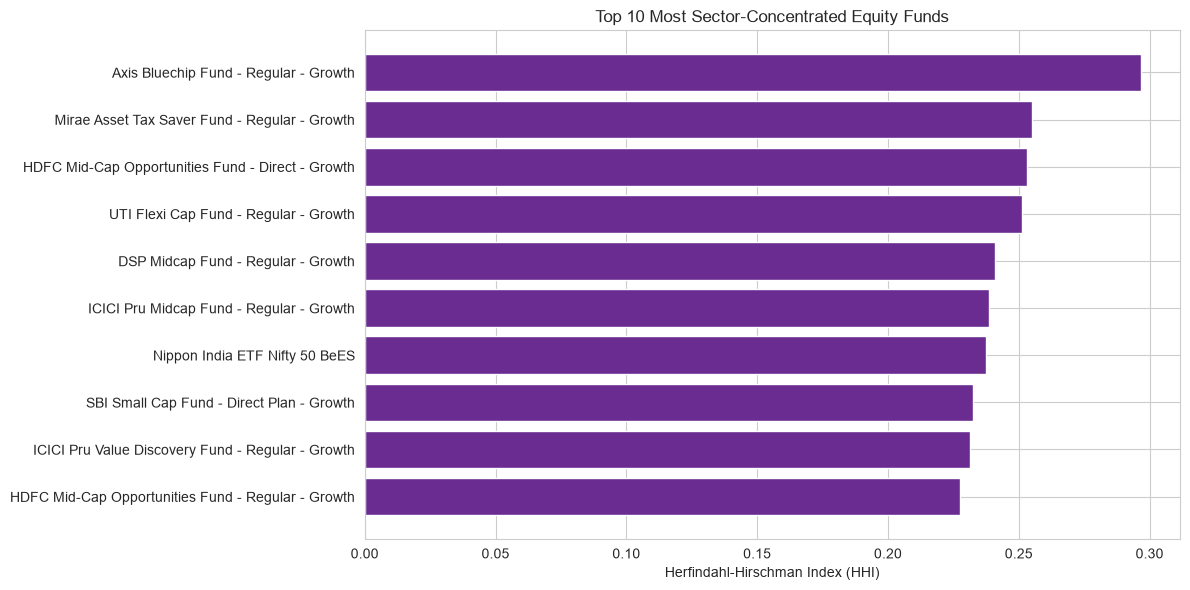

In [14]:
# Herfindahl-Hirschman Index per fund: sum of squared sector weights
# weight_pct is likely on a 0-100 scale, so we'll normalize to 0-1 first
portfolio["weight_frac"] = portfolio["weight_pct"] / 100

hhi = portfolio.groupby("amfi_code").apply(
    lambda g: (g.groupby("sector")["weight_frac"].sum() ** 2).sum(),
    include_groups=False
).reset_index(name="hhi")

hhi = hhi.merge(fund_master[["amfi_code", "scheme_name", "category"]], on="amfi_code")
hhi = hhi[["amfi_code", "scheme_name", "category", "hhi"]].sort_values("hhi", ascending=False)

print("Most sector-concentrated funds (highest HHI):")
print(hhi.head(10).to_string(index=False))

hhi.to_csv(REPORTS_DIR / "sector_hhi.csv", index=False)

# Chart: HHI for top 10 most concentrated funds
plt.figure(figsize=(12, 6))
top10 = hhi.head(10)
plt.barh(top10["scheme_name"], top10["hhi"], color="#6B2C91")
plt.xlabel("Herfindahl-Hirschman Index (HHI)")
plt.title("Top 10 Most Sector-Concentrated Equity Funds")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(CHARTS_DIR / "sector_hhi_chart.png", dpi=150)
plt.show()

Task 7: Advanced Analytics Summary (5 key insights)

## Advanced Analytics — Key Insights

1. **Small and Mid Cap equity funds carry the highest downside risk.** ABSL Small Cap Fund has the worst 95% VaR (-2.39% daily) and CVaR (-3.03%), consistent with Day 4's finding that Small Cap funds also show the deepest maximum drawdowns (up to -52.6%).

2. **Low-risk debt instruments underperformed the risk-free rate.** Contrary to expectation, the top "Low" risk_category funds (SBI Magnum Gilt, Nippon India Gilt, HDFC Short Term Debt) all show negative Sharpe ratios (-0.74 to -1.04), and Liquid funds show persistently negative rolling 90-day Sharpe ratios throughout 2022-2026. In this dataset, low-risk debt funds simply didn't generate enough absolute return to clear the 6.5% risk-free benchmark.

3. **Investor base and SIP commitment are both growing, but the dataset only captures a short window.** Cohort analysis shows 4,803 investors started in 2024 vs. 197 in 2025 (data spans ~Jan 2024-May 2025), and the smaller/newer 2025 cohort already shows a higher average SIP amount (₹13,505) than the 2024 cohort (₹10,997) — suggesting later joiners may be starting with stronger initial commitments.

4. **The brief's 35-day SIP continuity threshold doesn't fit this dataset's actual cadence.** Median gap between SIP transactions is 64.7 days, well above the 35-day mark, so a literal application flags 97.8% of eligible investors as "at-risk" — not a meaningful signal. Recalibrating to a relative threshold (top 25% of investors by gap width, >75.6 days) gives a more actionable at-risk figure of 25% (341 investors).

5. **Sector concentration is highest among large-cap and index-tracking funds.** Axis Bluechip Fund has the highest HHI (0.297), and even the Nifty 50 index ETF shows notable concentration (0.237) — a natural consequence of index/large-cap funds weighting toward the same dominant sectors (Banking, IT — consistent with Day 3's finding that these sectors made up ~45% of holdings combined).